<a href="https://colab.research.google.com/github/chrisBO4630/Machine-Learning-with-Python/blob/main/Kopie_von_6_Linnaeus_5_3_Layer_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Der 'Linnaeus 5 Dataset' – Ein Einblick in die Bildklassifizierung

Ja, ich bin mit dem **'Linnaeus 5 dataset'** sehr gut vertraut. Es handelt sich um einen populären Datensatz, der primär im Bereich der **Computer Vision** und des **Deep Learning** eingesetzt wird, insbesondere für Aufgaben der **Bildklassifizierung**. Sein Hauptzweck ist die Identifizierung und Kategorisierung von Pflanzenarten anhand visueller Merkmale.

### Namensgebung und Bedeutung

Der Name 'Linnaeus' ist eine Hommage an **Carl von Linné** (latinisiert Carolus Linnaeus), den berühmten schwedischen Botaniker, Arzt und Zoologen. Linné gilt als der Vater der modernen Taxonomie, da er das System der binären Nomenklatur etablierte, welches bis heute zur wissenschaftlichen Benennung von Organismen verwendet wird. Dieses System ordnet jedem Organismus einen zweiteiligen Namen zu, bestehend aus Gattung und Art.

Der Zusatz '5' im Datensatznamen deutet in der Regel darauf hin, dass dieser spezielle Datensatz **fünf unterschiedliche Klassen** (Kategorien oder Arten) von Pflanzen enthält. Dies könnte eine Teilmenge eines größeren Datensatzes sein oder eine spezifische Auswahl für bestimmte Lernziele. Für ein Bildklassifizierungsmodell bedeutet dies, dass es darauf trainiert wird, Bilder einer von diesen fünf vordefinierten Klassen zuzuordnen.

### Typische Struktur des Datensatzes

Ein typischerweise organisierter 'Linnaeus 5 dataset' besteht aus einer umfangreichen Sammlung von Bildern. Der entscheidende Aspekt seiner Struktur für maschinelles Lernen ist die **hierarchische Ordnerorganisation**:

1.  **Hauptverzeichnis**: Ein übergeordneter Ordner, der den gesamten Datensatz enthält (z.B. `Linnaeus_5`).
2.  **Unterverzeichnisse für Trainings- und Testdaten**: Innerhalb des Hauptverzeichnisses finden sich in der Regel zwei Schlüsselordner: `train` (Trainingsdaten) und `test` (Testdaten). Manchmal gibt es auch einen `validation`-Ordner, oder die Validierungsdaten werden aus dem `train`-Set gesplittet.
3.  **Klassenspezifische Unterordner**: Innerhalb der `train`- und `test`-Verzeichnisse (und ggf. `validation`) befinden sich weitere Unterordner. **Jeder dieser Unterordner repräsentiert eine der fünf spezifischen Pflanzenklassen** und enthält ausschließlich Bilder, die zu dieser bestimmten Klasse gehören.

Diese Struktur ist von entscheidender Bedeutung, da Bibliotheken wie TensorFlows `tf.keras.utils.image_dataset_from_directory` diese Ordnerstruktur nutzen, um automatisch die Bilder zu laden und ihnen die entsprechenden Labels (Klassennamen oder Integer-IDs) zuzuweisen. Das Modell lernt dann, welche visuellen Merkmale zu welcher Pflanzenart gehören, um sie in neuen, ungesehenen Bildern korrekt zu identifizieren.

### Wichtigkeit der korrekten Struktur

Wenn Sie diesen Datensatz für Ihr Deep-Learning-Modell verwenden, ist es absolut notwendig, die **korrekte Struktur der Unterordner und die Benennung der Klassen** zu gewährleisten. Eine Abweichung von dieser erwarteten Struktur (z.B. wenn alle Bilder direkt im `train`- oder `test`-Verzeichnis liegen, anstatt in klassenspezifischen Unterordnern) führt dazu, dass die Ladefunktionen die Bilder nicht den Klassen zuordnen können und Fehler wie `No images found in directory` auftreten. Die Integrität dieser Struktur beeinflusst direkt, wie TensorFlow die Daten interpretiert und verarbeitet, und ist somit entscheidend für den Erfolg des Trainings.

## Das Ergebnis

In diesem Projekt 6_Linnaeus_5.3.ipynb kommt das Model auf eine Accuracy von 0,68 und einem Loss von ca. 0,9.
In einem Weiteren Versuch ging es darum das Ergebnis zu verbessern.


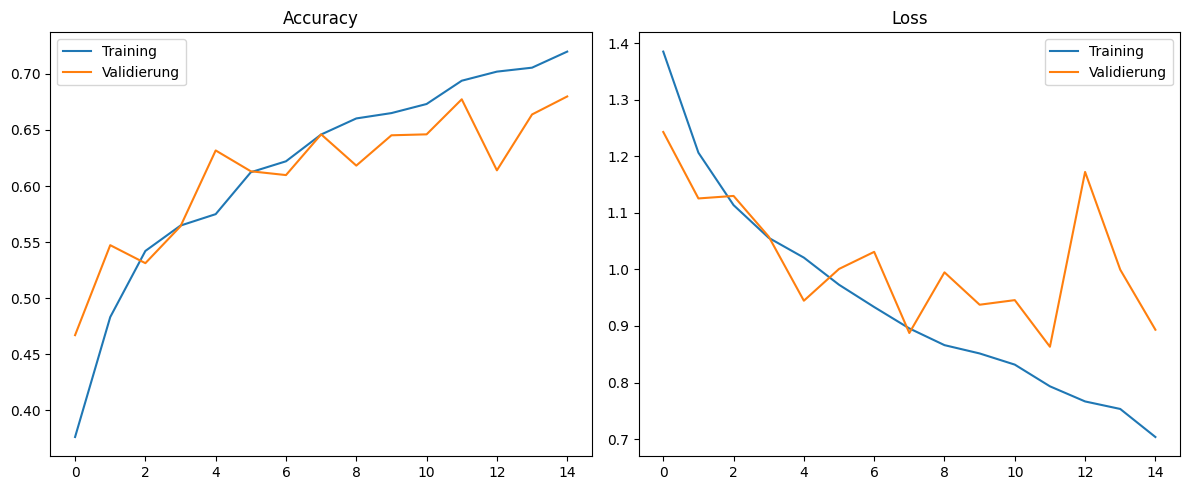

 ## Optimierung 1. Versuch

 ### 4-Layer-Model


In [ ]:
# =========================
# 1. Google Drive einbinden
# =========================
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# =========================
# 2. Bibliotheken importieren
# =========================
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os
import numpy as np

In [ ]:
# =========================
# 3. Pfade und Parameter
# =========================
base_dir = "/content/drive/MyDrive/Daten/Linnaeus_5" # Korrigierter Pfad
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

img_height = 128
img_width = 128
batch_size = 32
epochs = 30 # Der Ursprungswert war 15 Um eine größere Accuracy zu bekommen habe ich den Wert verdoppelt
num_classes = 5

tf.random.set_seed(42)

print("Train-Verzeichnis:", train_dir)
print("Test-Verzeichnis:", test_dir)
print("Train existiert:", os.path.exists(train_dir))
print("Test existiert:", os.path.exists(test_dir))

Train-Verzeichnis: /content/drive/MyDrive/Daten/Linnaeus_5/train
Test-Verzeichnis: /content/drive/MyDrive/Daten/Linnaeus_5/test
Train existiert: True
Test existiert: True


Den Datensatz habe ich selber von kaggle heruntergeladen. Dann entpackt und die Test- u. Trainingsdaten auf die zwei Verzeichnisse verteilt.

In [ ]:
# =========================
# 14. Inhalt der Trainingsverzeichnisse überprüfen
# =========================
import os

print(f"Inhalt von '{train_dir}':")
if os.path.exists(train_dir):
    # Liste alle direkten Unterordner auf, die Klassen repräsentieren sollten
    subdirs = [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))]
    if subdirs:
        print(f"Gefundene Unterordner (Klassen): {subdirs}")
        # Optional: Zeige die ersten paar Dateien im ersten Unterordner
        for subdir in subdirs:
            class_path = os.path.join(train_dir, subdir)
            files_in_class = [f for f in os.listdir(class_path) if os.path.isfile(os.path.join(class_path, f))]
            if files_in_class:
                print(f"  Beispielbilder in '{subdir}': {files_in_class[:5]}...")
            else:
                print(f"  Unterordner '{subdir}' ist leer oder enthält keine Dateien.")
            break # Nur für den ersten Unterordner anzeigen, um die Ausgabe kurz zu halten
    else:
        print("Keine Unterordner (Klassen) im Trainingsverzeichnis gefunden.")
        print("Direkte Dateien im Trainingsverzeichnis (falls vorhanden): ", os.listdir(train_dir)[:5])
else:
    print(f"Fehler: Trainingsverzeichnis '{train_dir}' existiert nicht.")

print(f"\nInhalt von '{test_dir}':")
if os.path.exists(test_dir):
    subdirs = [d for d in os.listdir(test_dir) if os.path.isdir(os.path.join(test_dir, d))]
    if subdirs:
        print(f"Gefundene Unterordner (Klassen): {subdirs}")
    else:
        print("Keine Unterordner (Klassen) im Testverzeichnis gefunden.")
        print("Direkte Dateien im Testverzeichnis (falls vorhanden): ", os.listdir(test_dir)[:5])
else:
    print(f"Fehler: Testverzeichnis '{test_dir}' existiert nicht.")

Inhalt von '/content/drive/MyDrive/Daten/Linnaeus_5/train':
Gefundene Unterordner (Klassen): ['bird', 'berry', 'dog', 'flower', 'other']
  Beispielbilder in 'bird': ['202_128.jpg', '201_128.jpg', '206_128.jpg', '207_128.jpg', '203_128.jpg']...

Inhalt von '/content/drive/MyDrive/Daten/Linnaeus_5/test':
Gefundene Unterordner (Klassen): ['flower', 'bird', 'other', 'berry', 'dog']


In [ ]:
# =========================
# 4. Trainings- und Testdaten laden
# =========================
train_ds_full = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    seed=42
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True
)

class_names = train_ds_full.class_names
print("Klassen:", class_names)

Found 6000 files belonging to 5 classes.
Found 2000 files belonging to 5 classes.
Klassen: ['berry', 'bird', 'dog', 'flower', 'other']


## Arbeiten mit Validierungsdaten

Unter "Validierungsdaten aus Trainingsdaten abspalten" versteht man einen sehr wichtigen Schritt im maschinellen Lernen und Deep Learning, der dazu dient, die Leistung eines Modells objektiv zu bewerten und Überanpassung (Overfitting) zu vermeiden.

Lassen Sie es mich genauer erklären:

*   **Trainingsdaten (Train Data)**: Dies ist der größte Teil Ihres Datensatzes. Das Modell wird mit diesen Daten "gefüttert", um zu lernen. Es passt seine internen Parameter (Gewichte und Biases in einem neuronalen Netz) an, um die Muster in diesen Daten zu erkennen und Vorhersagen zu treffen.

*   **Testdaten (Test Data)**: Dies ist ein kleiner Teil des Datensatzes, der komplett vom Training ferngehalten wird. Er wird erst am Ende des gesamten Entwicklungsprozesses verwendet, um die endgültige, unvoreingenommene Leistung des fertigen Modells zu bewerten. Er simuliert, wie gut das Modell auf wirklich neue, unbekannte Daten reagieren würde.

*   **Validierungsdaten (Validation Data)**: Hier kommt der entscheidende Punkt. Wenn Sie nur Trainings- und Testdaten hätten, müssten Sie das Modell trainieren, dann auf den Testdaten auswerten, Anpassungen vornehmen und wieder von vorne beginnen. Das würde dazu führen, dass Sie Ihr Modell (und Ihre Parameter) indirekt auf den Testdaten "optimieren", was wiederum zu einer überhöhten und unrealistischen Schätzung der Modellleistung führen würde (Overfitting an die Testdaten).

Deshalb spaltet man einen Teil der Trainingsdaten ab, um Validierungsdaten zu erhalten. Während des Trainings (oft nach jeder Epoche oder einer bestimmten Anzahl von Schritten) wird das Modell auf diesen Validierungsdaten ausgewertet. Die Ergebnisse auf den Validierungsdaten helfen Ihnen dabei:

*   **Überanpassung zu erkennen**: Wenn die Leistung auf den Trainingsdaten steigt, aber auf den Validierungsdaten stagniert oder sinkt, ist das ein starkes Zeichen für Overfitting.
*   **Hyperparameter abzustimmen**: Sie können anhand der Validierungsleistung entscheiden, welche Hyperparameter (z.B. Lernrate, Anzahl der Schichten, Dropout-Raten) am besten funktionieren.
*   **Modellauswahl**: Wenn Sie mehrere verschiedene Modelle ausprobieren, können Sie die Validierungsleistung nutzen, um das beste Modell auszuwählen, bevor Sie es endgültig auf den Testdaten bewerten.

Zusammenfassend:

*   **Trainingsdaten**: Zum Lernen des Modells.
*   **Validierungsdaten**: Zum Überwachen des Trainings, Anpassen von Hyperparametern und zur Modellauswahl, ohne die Testdaten zu "kontaminieren".
*   **Testdaten**: Zur finalen, unvoreingenommenen Bewertung der Modellleistung auf völlig ungesehenen Daten.

In [ ]:
# =========================
# 5. Validierungsdaten aus Trainingsdaten abspalten
# =========================
dataset_size = len(train_ds_full)
val_size = int(0.2 * dataset_size)

val_ds = train_ds_full.take(val_size)
train_ds = train_ds_full.skip(val_size)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Anzahl Trainings-Batches:", len(train_ds))
print("Anzahl Validierungs-Batches:", len(val_ds))
print("Anzahl Test-Batches:", len(test_ds))

Anzahl Trainings-Batches: 151
Anzahl Validierungs-Batches: 37
Anzahl Test-Batches: 63


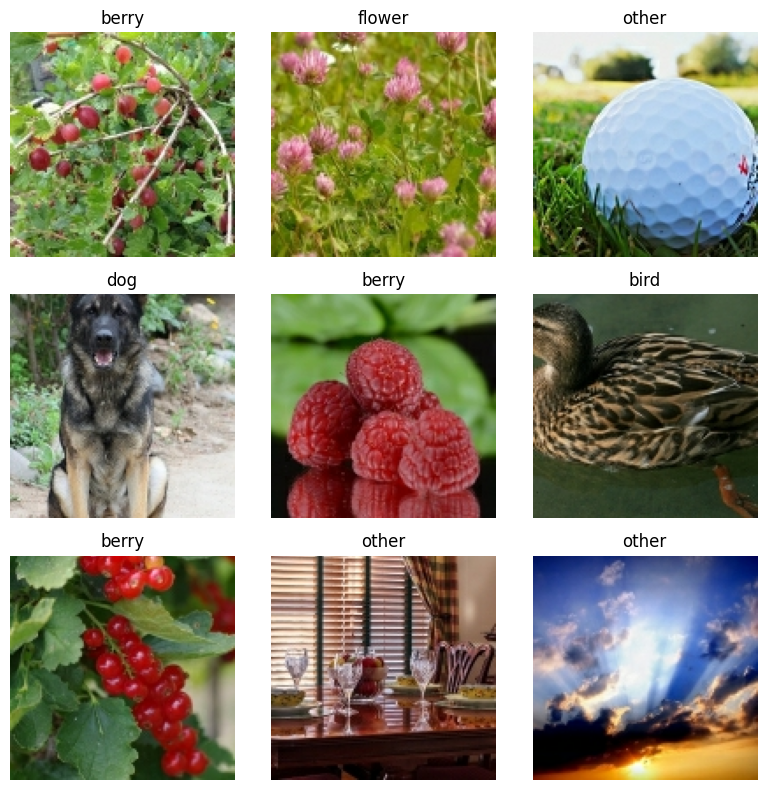

In [ ]:
# =========================
# 6. Beispielbilder anzeigen
# =========================
plt.figure(figsize=(8, 8))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.tight_layout()
plt.show()

16 Minuten für das Laden der Bilder ist tatsächlich eine sehr lange Zeit! Das ist eine wichtige Beobachtung und es gibt mehrere Gründe, die dazu beitragen können, insbesondere nach der Umstellung auf 128x128 Pixel:

1.  **I/O-Engpass von Google Drive (Hauptursache)**:
    *   Der größte Faktor ist nach wie vor das **Lesen von vielen kleinen Bilddateien direkt aus Google Drive**. Jede Datei muss einzeln geöffnet und übertragen werden. Google Drive ist nicht für eine hohe Geschwindigkeit beim Zugriff auf Tausende von kleinen Dateien optimiert, und die Performance kann in Colab variieren.
    *   Die `tf.data.Dataset`-Pipeline mit `cache()` und `prefetch()` ist darauf ausgelegt, dies zu mildern, aber der *erste* Durchlauf, der den Cache füllt, muss trotzdem alle Daten von der Quelle (Google Drive) holen. Für 6000 Trainingsbilder und 2000 Testbilder (insgesamt 8000 Bilder) summiert sich das.

2.  **Erhöhte Bildgröße (128x128 Pixel)**:
    *   Sie haben die Bildgröße von 64x64 auf 128x128 Pixel erhöht. Das bedeutet, dass **jedes Bild nun viermal so viele Pixel** hat (128*128 = 16384 Pixel vs. 64*64 = 4096 Pixel). Obwohl Ihre Originalbilder bereits 128x128 Pixel waren, muss die `tf.keras.utils.image_dataset_from_directory`-Funktion diese Daten trotzdem verarbeiten, d.h., sie muss die größere Datenmenge lesen und eventuell dekodieren.
    *   Eine größere Bildgröße bedeutet mehr Daten, die von Google Drive übertragen, im Speicher gehalten und verarbeitet werden müssen. Dies hat einen direkten Einfluss auf die Ladezeit.

3.  **CPU-Verarbeitung beim Laden**:
    *   `tf.keras.utils.image_dataset_from_directory` übernimmt nicht nur das Lesen der Bytes von der Festplatte (oder Drive), sondern auch die **Dekodierung der Bildformate** (z.B. JPG, PNG) in Pixeldaten, das **Resizing** (wenn die `image_size` nicht der Originalgröße entspricht) und das **Batching**. Diese Schritte sind CPU-intensiv. Bei 8000 Bildern, die nun viermal mehr Pixel haben, steigt die benötigte CPU-Zeit erheblich.

4.  **Colab-Ressourcen**: Die Ihnen in Colab zugewiesenen CPU-Ressourcen können variieren. Manchmal ist die I/O-Leistung zu Google Drive oder die verfügbare CPU-Leistung geringer, was solche Vorgänge zusätzlich verlangsamen kann.

**Zusammenfassend:** Die Kombination aus dem langsamen Lesen vieler kleiner Dateien von Google Drive, der jetzt vierfach größeren Datenmenge pro Bild (im Vergleich zu 64x64) und der CPU-intensiven Dekodierung/Verarbeitung führt zu dieser extrem langen initialen Ladezeit.

**Die gute Nachricht:** Da Sie `cache()` verwenden, sollte das Training selbst, also die Epochen, die auf diesen Datensätzen laufen, *deutlich* schneller ablaufen. Die Bilder sollten jetzt im Arbeitsspeicher (oder einem schnellen Zwischenspeicher) vorliegen und nicht jedes Mal erneut von Google Drive gelesen werden müssen.

## Das Fließband der neuronalen Netze
###Das keras.Sequential-Modell
ist die grundlegendste und am häufigsten genutzte Architektur, um neuronale Netze in Keras (und damit in TensorFlow) aufzubauen. Der Name "Sequential" (zu Deutsch: aufeinanderfolgend) beschreibt genau, wie es funktioniert: Es ist ein streng linearer Stapel von Schichten (Layers). Du kannst es dir wie einen Turm aus Legosteinen oder ein Fließband vorstellen.

### Der Datenfluss
Ein Bild betritt das Netzwerk in der ersten Schicht (der Eingabeschicht). Dort werden erste mathematische Operationen durchgeführt, und das Ergebnis wird direkt an die zweite Schicht weitergereicht. Dieser Prozess wiederholt sich Schicht für Schicht – streng geordnet, ohne Abzweigungen, ohne Schleifen und ohne dass Schichten übersprungen werden. Am Ende des Fließbands liefert die letzte Schicht (die Ausgabeschicht) die finale Vorhersage, also zu welcher der fünf Linnaeus-Klassen das Bild am wahrscheinlichsten gehört.

### Warum wir es nutzen
Intuitive Programmierung: Es ist unfassbar anfängerfreundlich und logisch aufgebaut. Du definierst das Modell einmal und fügst dann Schicht für Schicht hinzu. Der Code bleibt extrem sauber und übersichtlich.
Ideal für klassische Bilderkennung: Für dein Projekt brauchst du höchstwahrscheinlich ein Convolutional Neural Network (CNN). Solange du ein typisches CNN baust, bei dem Faltungs- und Pooling-Schichten einfach linear hintereinanderliegen, ist das Sequential-Modell das absolut perfekte Werkzeug.
Die Grenzen des Modells
Sequential ist absichtlich einfach gehalten. Es stößt an seine Grenzen bei komplexen Architekturen, die mehrere verschiedene Eingaben gleichzeitig benötigen, mehrere separate Ausgaben erzeugen oder bei denen sich der Datenfluss im Netzwerk verzweigt (sogenannte Skip Connections, die in sehr tiefen Netzen vorkommen). Wenn wir so etwas bauen müssten, würden wir stattdessen die flexiblere Keras Functional API verwenden.
Für dein aktuelles Linnaeus-Projekt ist das Sequential-Modell aber exakt die richtige Wahl. Es hält den Code elegant, während du dich voll auf das Experimentieren mit den einzelnen Schichten konzentrieren kannst!

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# =========================
# 7. Modell definieren (Optimierte 4-Layer-Version)
# =========================

# Data Augmentation bleibt als Schutz gegen Overfitting wichtig
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

model = keras.Sequential([
    # Eingabeschicht
    layers.Input(shape=(img_height, img_width, 3)),

    # Vorverarbeitung
    data_augmentation,
    layers.Rescaling(1.0 / 255),

    # --- BLOCK 1: Einfache Strukturen ---
    layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    # --- BLOCK 2: Formen & Muster ---
    layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    # --- BLOCK 3: Komplexere Merkmale ---
    layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    # --- BLOCK 4: Abstraktes Wissen (Die neue 4. Schicht) ---
    # Wir erhöhen auf 256 Filter, um feinere Details der Linnaeus-Klassen zu trennen
    layers.Conv2D(256, (3, 3), activation="relu", padding="same"),
    layers.MaxPooling2D(),

    # --- KLASSIFIKATION ---
    layers.Flatten(),
    # Ein größerer Dense-Layer (256 statt 128), passend zur Tiefe des Netzes
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5), # Leicht erhöhter Dropout, da das Modell jetzt "schlauer" ist
    layers.Dense(num_classes, activation="softmax")
])

# Zusammenfassung anzeigen
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_4 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,584,261 (17.49 MB)

 Trainable params: 4,584,261 (17.49 MB)

 Non-trainable params: 0 (0.00 B)

__Data Augmentation:__ Zufälliges Spiegeln, Drehen und Zoomen zur Vermeidung von Overfitting.

__Rescaling:__ Normalisierung der Pixelwerte von [0, 255] auf [0, 1].

### Verbesserungen

__Feature Extraction (3 Blöcke):__

Conv2D: Filtert Merkmale (Kanten, Formen) aus den Bildern (32, 64, 128 bis hin zu 256 Filter).

__hier die Verdopplung der Dense-Neuronen!__

MaxPooling2D: Reduziert die Bildgröße und behält nur die wichtigsten Informationen bei.

__Flatten:__
Umwandlung der 2D-Feature-Maps in einen flachen 1D-Vektor.

__Dense (256):__
Vergrößerte vollvernetzte Schicht zur Kombination der
erkannten Merkmale.

__Dropout (0.5):__
 Schaltet 50 % der Neuronen im Training ab, um die Generalisierung zu verbessern.

__Output (Dense 5):__
 Abschließende Schicht mit Softmax-Aktivierung zur Berechnung der Wahrscheinlichkeiten für die 5 Klassen

### Vorheriges Setup

__Data Augmentation:__ Zufälliges Spiegeln, Drehen und Zoomen zur Vermeidung von Overfitting.

__Rescaling:__ Normalisierung der Pixelwerte von [0, 255] auf [0, 1].

__Feature Extraction (3 Blöcke):__

Conv2D: Filtert Merkmale (Kanten, Formen) aus den Bildern (32, 64, 128 Filter).

MaxPooling2D: Reduziert die Bildgröße und behält nur die wichtigsten Informationen bei.

__Flatten:__ Umwandlung der 2D-Feature-Maps in einen flachen 1D-Vektor.

__Dense (128):__ Vollvernetzte Schicht zur Kombination der erkannten Merkmale.

__Dropout (0.3):__ Schaltet 30 % der Neuronen im Training ab, um die Generalisierung zu verbessern.

__Output (Dense 5):__ Abschließende Schicht mit Softmax-Aktivierung zur Berechnung der Wahrscheinlichkeiten für die 5 Klassen.

In [ ]:
# =========================
# 8. Modell kompilieren
# =========================
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# =========================
# 9. Training
# =========================
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 29s 47ms/step - accuracy: 0.3272 - loss: 1.4412 - val_accuracy: 0.4333 - val_loss: 1.3076
Epoch 2/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.4230 - loss: 1.3171 - val_accuracy: 0.4628 - val_loss: 1.2514
Epoch 3/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.4649 - loss: 1.2317 - val_accuracy: 0.5144 - val_loss: 1.1315
Epoch 4/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.5106 - loss: 1.1617 - val_accuracy: 0.5236 - val_loss: 1.1318
Epoch 5/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5357 - loss: 1.1126 - val_accuracy: 0.5921 - val_loss: 1.0247
Epoch 6/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5621 - loss: 1.0605 - val_accuracy: 0.5760 - val_loss: 1.0014
Epoch 7/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.5831 - loss: 1.0120 - val_accuracy: 0.5954 - val_loss: 1.0220
Epoch 8/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5941 - loss: 0.9897 - val_acc

### In Zelle bereiten wir das Modell auf das Training vor.

Als Laufzeittyp ist die GPU ausgewählt.
Benötigte Zeit ca. 1 Minute.

Da das Training durch die Nutzung der GPU viel schneller erfolgt erhöhen ich die Anzahl der Epochen um das Doppelte auf 30!

Man kann sich das wie die Vorbereitung eines Sportlers auf einen Wettkampf vorstellen:

* __compile__ (Kompilieren): Das ist der Schritt, in dem das Modell seine 'Marschbefehle' erhält. Hier wird festgelegt, wie das Modell lernt, wie es Fehler misst und wie es seinen Erfolg bewertet. Ohne diesen Schritt kann das Training (fit) nicht starten.

* __optimizer__ (Optimierer - hier 'adam'): Das ist der Algorithmus, der die Gewichte des Netzwerks anpasst, um den Fehler zu minimieren. 'Adam' ist ein sehr beliebter Standard-Optimierer, der die Lernrate automatisch anpasst.

* __loss__ (Verlustfunktion - hier 'sparse_categorical_crossentropy'):
Das ist der mathematische Maßstab für den Fehler. Er sagt dem Modell, wie weit seine Vorhersage vom richtigen Ergebnis entfernt ist. Das Ziel des Trainings ist es, diesen Wert so klein wie möglich zu machen. 'Sparse Categorical Crossentropy' wird verwendet, wenn man Bilder in mehrere Kategorien (Klassen) einteilt und die Labels als Zahlen (0, 1, 2...) vorliegen.

* __metrics__ (Metriken - hier ['accuracy']):
Das sind die Werte, die wir als Menschen lesen, um die Leistung zu beurteilen. 'Accuracy' (Genauigkeit) gibt einfach an, wie viel Prozent der Bilder das Modell korrekt erkannt hat. Während das Modell den loss minimiert, hoffen wir, dass die accuracy steigt.

In [ ]:
# =========================
# 10. Auswertung auf Testdaten
# =========================
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test-Loss: {test_loss:.4f}")
print(f"Test-Accuracy: {test_acc:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - accuracy: 0.7265 - loss: 0.8705
Test-Loss: 0.8705
Test-Accuracy: 0.7265


1. Test-Accuracy: 0,6440 (ca. 64 %)
Vergleich zu 3 Schicht-Modell 68%

Das bedeutet, dass dein Modell bei fast 65 von 100 Bildern die richtige Klasse erkennt.

2. Bei 30 Epochen kommen wir auf eine Accuracy von 0,72

Ist das gut?

_Da wir 5 Klassen haben, läge die Wahrscheinlichkeit bei reinem Raten bei nur 20 %. Dein Modell ist also mit 68 % deutlich besser als der Zufall.
Einordnung: Für ein erstes einfaches Modell auf diesem Datensatz ist das ein solider Start, aber es gibt noch viel Luft nach oben (Profi-Modelle erreichen hier oft über 90 %)._

__Test-Loss: 0,9239__

Vergleich 3-Layer-Model : 0,8832

Vergleich 4-Layer-Model mit 30 Epochen : 0,87 !


Der Loss ist schwerer absolut zu bewerten, da er kein Prozentsatz ist, sondern die 'Unsicherheit' des Modells ausdrückt.

_Ein Wert von 0,92 ist wenig moderat. Wäre er nahe bei 0, wäre das Modell sehr sicher und fast immer korrekt. Wäre er deutlich über 1,5 oder 2,0, würde das Modell sehr oft komplett daneben liegen oder sehr unsicher sein.
Wichtig ist der Vergleich: Bei Epoch 15/15 sahen wir am Ende des Trainings einen val_loss von ca. 0,89. Dass der Test-Loss (0,88) fast identisch ist, ist ein sehr gutes Zeichen! Es bedeutet, dass dein Modell stabil ist und auf den Testdaten genauso gut funktioniert wie auf den Validierungsdaten während des Trainings (kein extremes Overfitting auf die Validierungsdaten)._



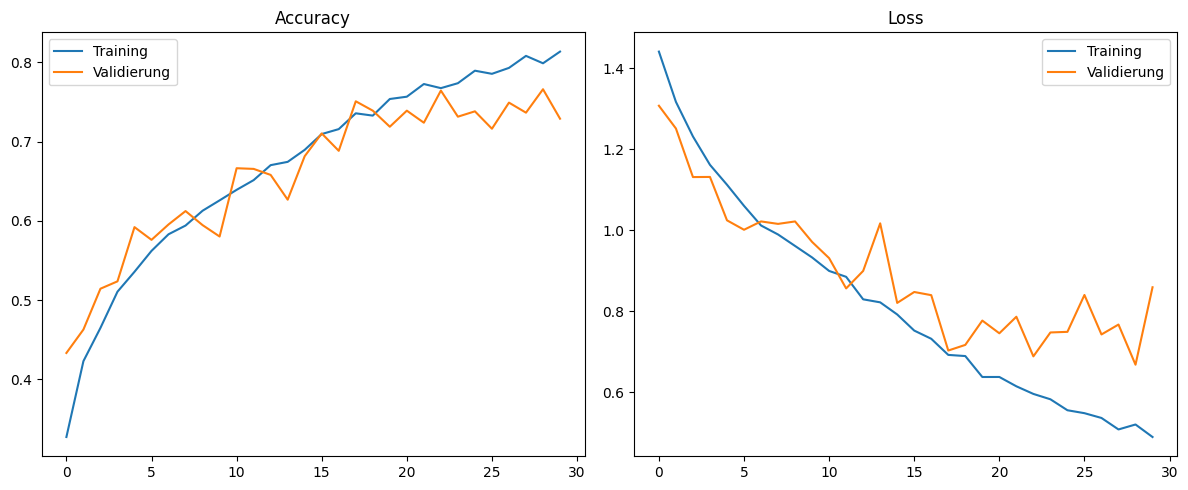

In [ ]:
# =========================
# 11. Trainingsverlauf darstellen
# =========================
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Training")
plt.plot(epochs_range, val_acc, label="Validierung")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Training")
plt.plot(epochs_range, val_loss, label="Validierung")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()

###Zusammenfassung

Dein Modell hat erfolgreich gelernt, Muster zu erkennen! Es ist kein 'Rategenerator' mehr, sondern ein funktionierender Klassifikator.
Um die 72 % zu steigern, könnte man nun das Training länger laufen lassen.

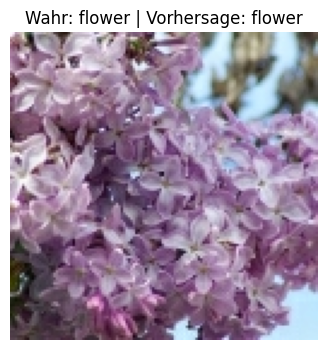

Klassenzugehörigkeiten:
berry: 0.0000
bird: 0.0000
dog: 0.0000
flower: 1.0000
other: 0.0000


In [ ]:
# =========================
# 12. Einzelne Vorhersage anzeigen
# =========================
for images, labels in test_ds.take(1):
    sample_image = images[0]
    sample_label = labels[0]

    prediction = model.predict(tf.expand_dims(sample_image, axis=0), verbose=0)
    predicted_index = tf.argmax(prediction[0]).numpy()

    plt.figure(figsize=(4, 4))
    plt.imshow(sample_image.numpy().astype("uint8"))
    plt.title(f"Wahr: {class_names[sample_label.numpy()]} | Vorhersage: {class_names[predicted_index]}")
    plt.axis("off")
    plt.show()

    print("Klassenzugehörigkeiten:")
    for i, prob in enumerate(prediction[0]):
        print(f"{class_names[i]}: {prob:.4f}")

Damit die Bilder zufällig ausgewählt werden, habe ich im Programmabschnitt "4. Trainings- und Testdaten laden" beim Ladens des Test-Datensatzes __shuffle=True__ eingestellt.